# Case Study 1 — Analytical strategy based on reduced EEG features

This notebook implements the analysis described in Section 4.1 of the
companion paper. 

The research question is:

> *Are the amplitude and latency of specific ERP components associated with neuropsychological performance and demographic characteristics in post-stroke patients?*

Two well-characterised ERP components are used:
- **N400** — a negative deflection ~400 ms post-stimulus, indexing semantice
  processing (Kutas & Federmeier, 2011)
- **P300** — a positive deflection ~300 ms post-target, indexing attentional
  resource allocation (Polich, 2007)

From each component we consider **amplitude** (mean µV within a predefined
time window) and **latency** (ms of peak amplitude), yielding four
participant-level neural predictors.

As it usually happens in real life, data are delivered in two different files: `dataset_NPSY.csv` and `dataset_ERP.csv`.


## Pipeline

1. **Data Wrangling** — load, inspect, check ranges, missing data, distributions,
   outliers, multicollinearity
2. **Analysis** — descriptive stats, bivariate correlations, multiple regression,
   diagnostics, multiple comparison correction
3. **Export** — save tables and figures

> All code is defined directly in this notebook for transparency and
> reproducibility. Each step is explained as we go.


## 0. Setup

Import the libraries we will use throughout the analysis.

In [1]:
# System library
from pathlib import Path
# Standard numeric libraries
import numpy as np
import pandas as pd
# Statistical libraries
from scipy.stats import pearsonr, shapiro, zscore, chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.tools.tools import add_constant
# Plot library
import seaborn as sns
import matplotlib.pyplot as plt

Define input/output folders

In [4]:
# Input
DATA_DIR = Path("../../data")
NPSY_CSV = DATA_DIR / "dataset_NPSY.csv"
EEG_CSV = DATA_DIR / "dataset_ERP.csv"
# Output
OUTPUTS = Path("CaseStudy_1") / "outputs"
FIGS    = OUTPUTS / "figures"
RESULTS = OUTPUTS / "results"
# Create output folders if they do not exist
FIGS.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

---
## 1. Data Wrangling

### 1.1 Load data

The datasets are stored as separate CSV files linked by `subject_id`.

In [5]:
npsy = pd.read_csv(NPSY_CSV)
eeg  = pd.read_csv(EEG_CSV)
print(f"NPSY: {npsy.shape}  columns: {list(npsy.columns)}")
print(f"EEG:  {eeg.shape}  columns: {list(eeg.columns)}")

NPSY: (40, 7)  columns: ['subject_id', 'age', 'sex', 'criq', 'apacs', 'att_matr', 'moca']
EEG:  (40, 5)  columns: ['subject_id', 'n400_amp', 'n400_lat', 'p300_amp', 'p300_lat']


Let's inspect the datasets looking at the first rows: each row stores the NPSY/EEG data of a single subject.

In [6]:
print("NPSY")
print(npsy.head())
print("EEG")
print(eeg.head())

NPSY
  subject_id   age  sex   criq   apacs  att_matr   moca
0    sub-001  68.0    0  108.5  0.8207      51.0  29.89
1    sub-002  55.0    1   98.4  0.7716      46.0  15.14
2    sub-003  73.0    1  104.5  0.7531      43.0  26.26
3    sub-004  74.0    0   87.4  0.7062      25.0  14.98
4    sub-005  45.0    1  100.6  0.8480      61.0  27.08
EEG
  subject_id  n400_amp  n400_lat  p300_amp  p300_lat
0    sub-001     4.781     419.0    12.491     335.6
1    sub-002     3.309     402.2    12.206     337.1
2    sub-003     2.681     414.5    13.108     340.8
3    sub-004     3.643     418.6    15.033     353.1
4    sub-005     3.676     446.9    12.663     313.6


To create a single dataset we need to merge on `subject_id` the data collected for each subject

In [7]:
df = pd.merge(npsy, eeg, on="subject_id", how="inner")
print(f"Merged: {df.shape[0]} subjects × {df.shape[1]} variables")
df.head()

Merged: 40 subjects × 11 variables


,subject_id,age,sex,criq,apacs,att_matr,moca,n400_amp,n400_lat,p300_amp,p300_lat
0,sub-001,68.0,0,108.5,0.8207,51.0,29.89,4.781,419.0,12.491,335.6
1,sub-002,55.0,1,98.4,0.7716,46.0,15.14,3.309,402.2,12.206,337.1
2,sub-003,73.0,1,104.5,0.7531,43.0,26.26,2.681,414.5,13.108,340.8
3,sub-004,74.0,0,87.4,0.7062,25.0,14.98,3.643,418.6,15.033,353.1
4,sub-005,45.0,1,100.6,0.8480,61.0,27.08,3.676,446.9,12.663,313.6


### 1.2 Initial inspection

We check dataset dimensions, column types, and basic descriptive statistics.

**Expected clinical ranges:**

| Variable           | Expected range  |
|--------------------|-----------------|
| Age                | 18–100 years    |
| CRIq               | 70–130          |
| N400 amplitude     | 1–6 µV          |
| N400 latency       | 350–500 ms      |
| P300 amplitude     | 5–20 µV         |
| P300 latency       | 300–500 ms      |
| APACS              | 0–1             |
| Attentive Matrices | 0–60            |
| MoCA               | 0–30            |


In [8]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(f"\nFirst 5 rows:")
print(df.head().to_string())
print(f"\nDescriptive statistics:")
df.describe()

Shape: 40 rows × 11 columns


First 5 rows:
  subject_id   age  sex   criq   apacs  att_matr   moca  n400_amp  n400_lat  p300_amp  p300_lat
0    sub-001  68.0    0  108.5  0.8207      51.0  29.89     4.781     419.0    12.491     335.6
1    sub-002  55.0    1   98.4  0.7716      46.0  15.14     3.309     402.2    12.206     337.1
2    sub-003  73.0    1  104.5  0.7531      43.0  26.26     2.681     414.5    13.108     340.8
3    sub-004  74.0    0   87.4  0.7062      25.0  14.98     3.643     418.6    15.033     353.1
4    sub-005  45.0    1  100.6  0.8480      61.0  27.08     3.676     446.9    12.663     313.6

Descriptive statistics:


,age,sex,criq,apacs,att_matr,moca,n400_amp,n400_lat,p300_amp,p300_lat
count,40.000000,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,65.375000,0.50000,96.015000,0.746600,36.875000,21.632500,3.509825,426.012500,12.330400,350.270000
std,8.266979,0.50637,11.337335,0.073869,11.435858,6.101318,0.874654,14.796087,1.769591,18.056581
min,45.000000,0.00000,73.500000,0.569300,5.000000,8.170000,1.794000,402.100000,8.635000,313.600000
25%,59.500000,0.00000,88.225000,0.685425,29.000000,17.705000,2.827250,415.525000,11.232250,336.775000
50%,65.500000,0.50000,97.050000,0.756250,36.000000,21.655000,3.422000,424.200000,12.214500,349.500000
75%,71.250000,1.00000,104.850000,0.799550,45.250000,25.802500,4.048000,437.425000,13.078000,359.850000
max,86.000000,1.00000,120.100000,0.880200,61.000000,30.000000,5.831000,453.200000,17.031000,398.100000


From the automatic pandas description we see that all parameters are within the expected ranges.

However looking at each variable is not the most suitable way to validate data: we can perform a simple automatic check on the allowed ranges. 

In [9]:
# Range check — flag values outside expected physiological limits
ranges = {
    "age":      (18, 100),
    "criq":     (70, 130),
    "n400_amp": (0.5, 8),
    "n400_lat": (300, 550),
    "p300_amp": (3, 25),
    "p300_lat": (250, 550),
    "apacs":    (0, 1),
    "att_matr": (0, 60),
    "moca":     (0, 30),
}
print("Range checks:")
any_warn = False
# Loop over all the variables
for col, (lo, hi) in ranges.items():
    if col not in df.columns: continue
    # Check if there is any value outside the defined range
    below = (df[col].dropna() < lo).sum()
    above = (df[col].dropna() > hi).sum()
    if below: print(f"  ⚠ {col}: {below} values below {lo}"); any_warn = True
    if above: print(f"  ⚠ {col}: {above} values above {hi}"); any_warn = True
if not any_warn:
    print("  All values within expected ranges.")


Range checks:
  ⚠ att_matr: 1 values above 60


### 1.3 Missing data (DECIDERE SE ELIMINARE)

Missing data are common in clinical neuropsychological datasets — they can
arise from fatigue, incomplete testing, or participant dropout. Strategies
include:

- **Listwise deletion** (exclude participants with any missing value) —
  simple, but reduces sample size and may bias estimates if data are not
  missing completely at random (MCAR).
- **Multiple imputation** (e.g., MICE) — preserves sample size and is
  valid under the weaker assumption of missing at random (MAR). Generally
  preferred in clinical samples.

Our synthetic dataset has complete data for all 40 participants, so no
imputation is needed here. The code below would work with either scenario.

Visual inspection of missing data patterns:

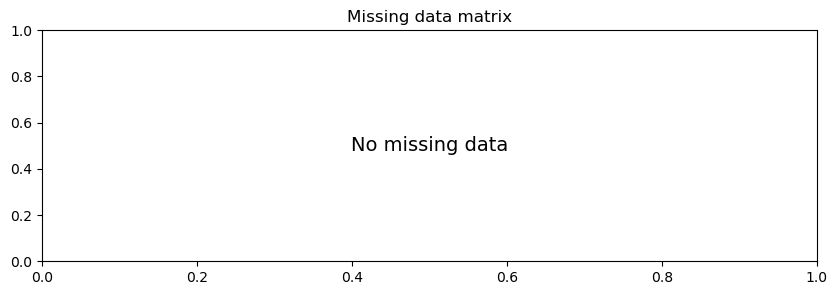

In [10]:
fig_missing, ax = plt.subplots(figsize=(10, 3))
if df.isnull().sum().sum() == 0:
    ax.text(0.5, 0.5, "No missing data", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
else:
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing data matrix")
plt.show()

In [11]:
print(f"{'Variable':<25} {'Missing':>8} {'Rate':>8}")
print("-" * 43)
for col in df.columns:
    n_miss = df[col].isnull().sum()
    print(f"{col:<25} {n_miss:>8} {n_miss/len(df)*100:>7.1f}%")


Variable                   Missing     Rate
-------------------------------------------
subject_id                       0     0.0%
age                              0     0.0%
sex                              0     0.0%
criq                             0     0.0%
apacs                            0     0.0%
att_matr                         0     0.0%
moca                             0     0.0%
n400_amp                         0     0.0%
n400_lat                         0     0.0%
p300_amp                         0     0.0%
p300_lat                         0     0.0%


### 1.4 Distribution check

More than just plotting the data we can already perform a quality check by looking at the Q-Q plots, and running the Shapiro-Wilk normality test. This guides later decisions about
transformations and correlation methods.


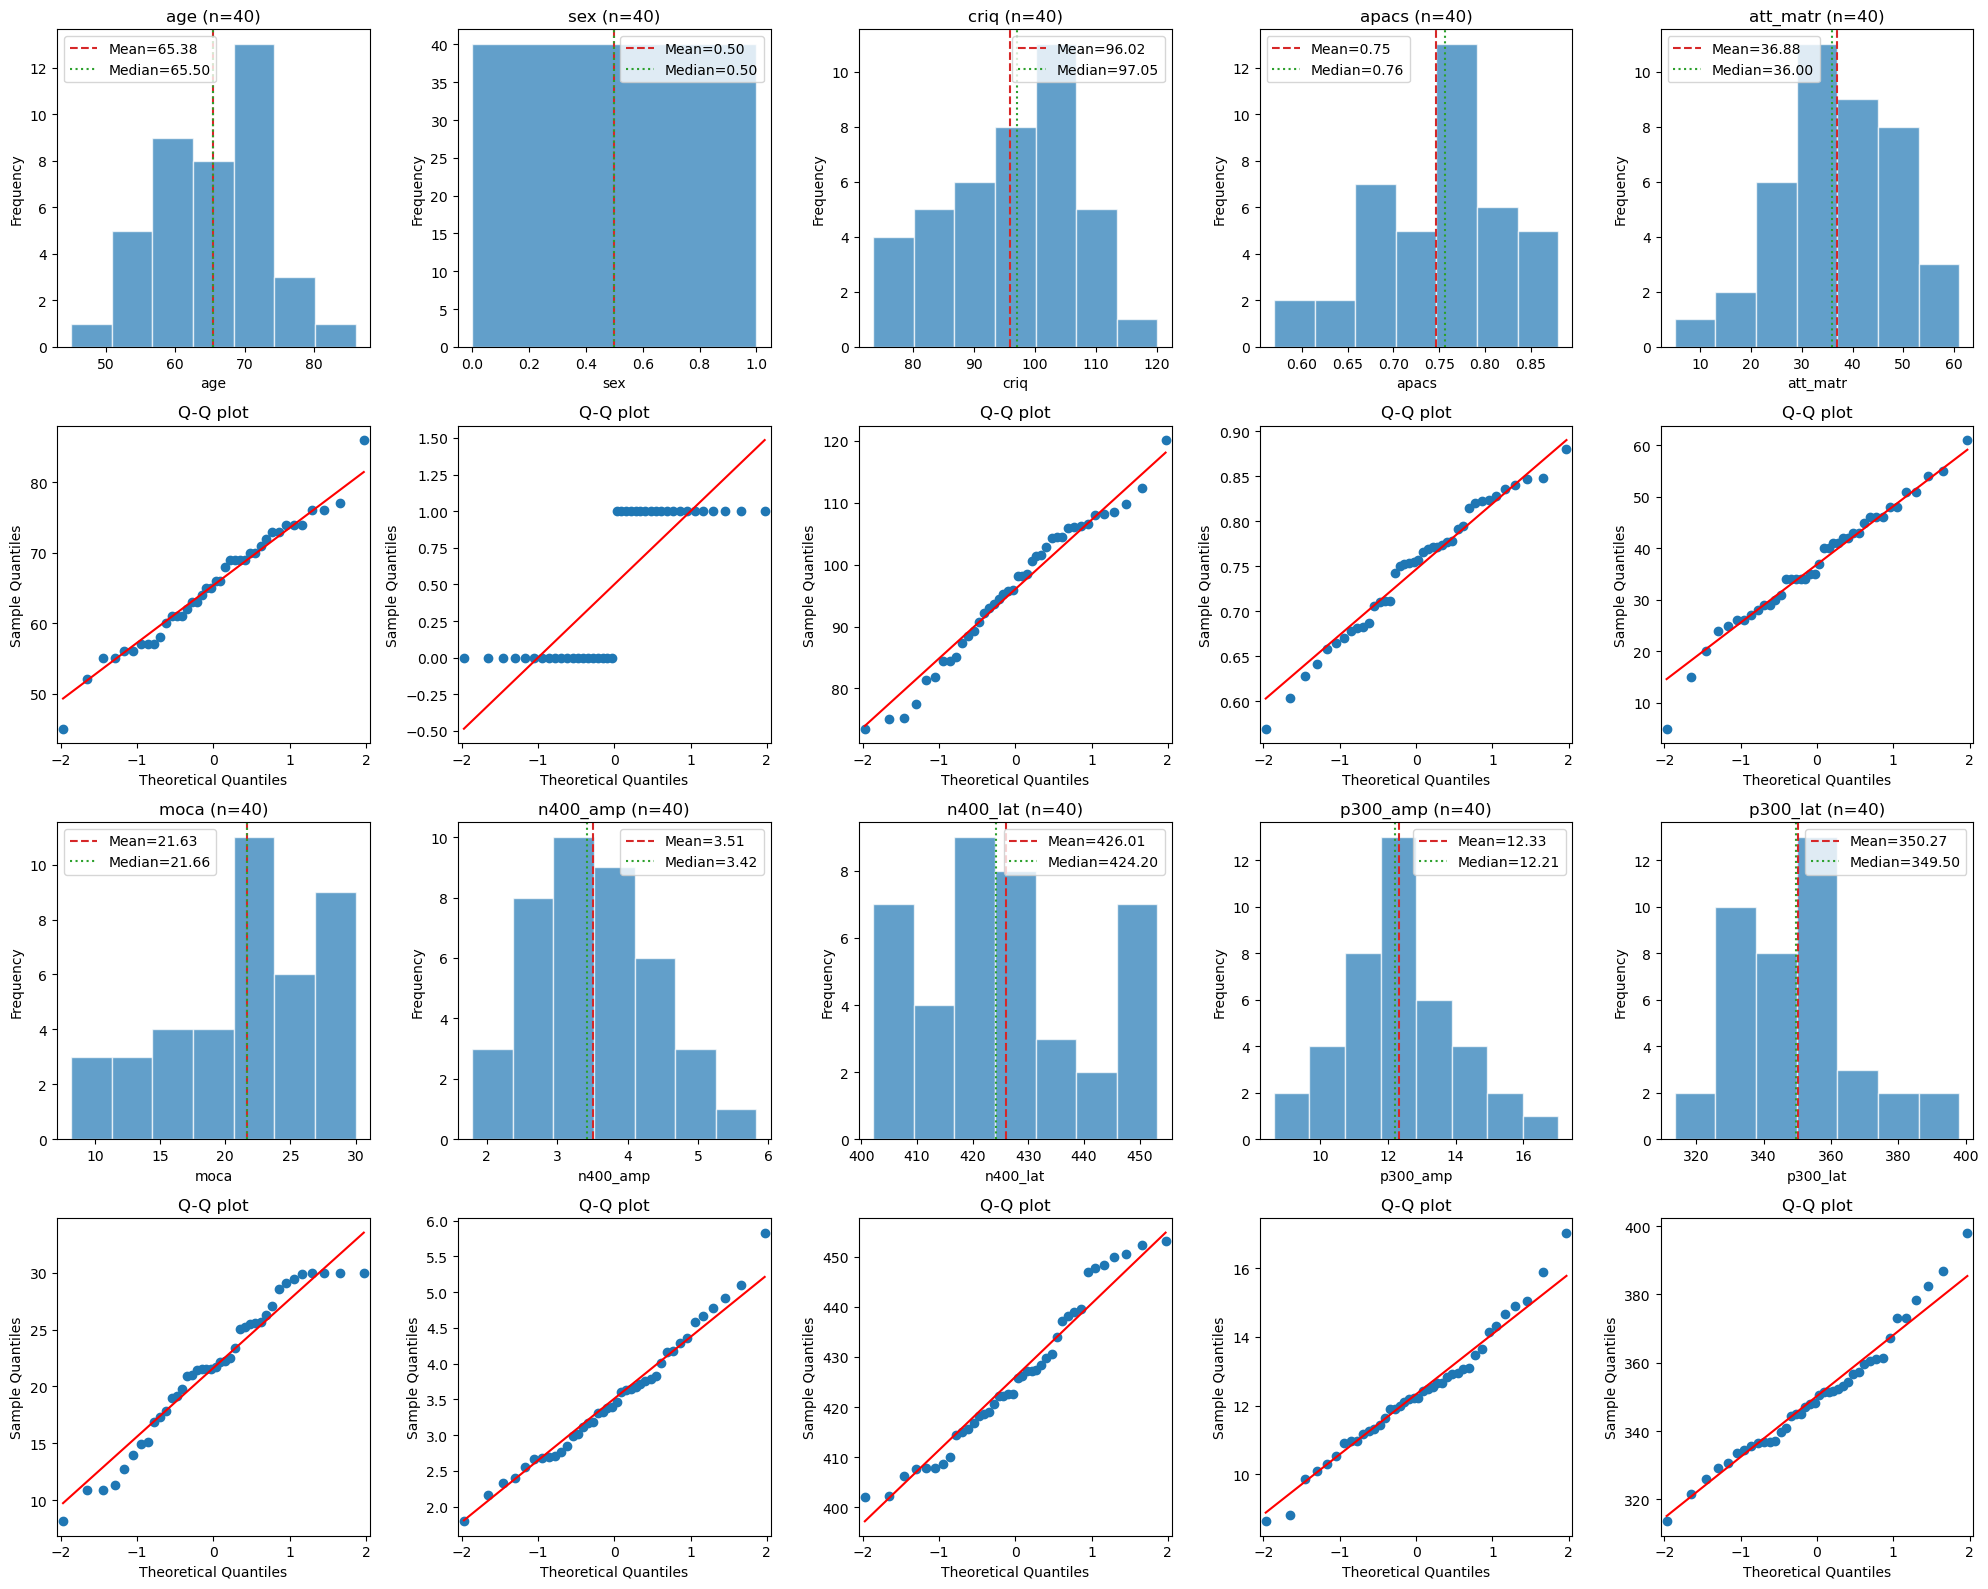

In [12]:
vars = ["age", "sex", "criq", "apacs", "att_matr", "moca", "n400_amp", "n400_lat", "p300_amp", "p300_lat"]
fig_dist, axes = plt.subplots(2*2, 5, figsize=(20,16))

for i, col in enumerate(vars):
    v = df[col].dropna()
    # histogram
    ax = axes[int(i/5)*2, i%5]
    ax.hist(v, bins="auto", edgecolor="white", alpha=0.7)
    ax.axvline(v.mean(), color="C3", ls="--", label=f"Mean={v.mean():.2f}")
    ax.axvline(v.median(), color="C2", ls=":", label=f"Median={v.median():.2f}")
    ax.set_title(f"{col} (n={len(v)})")
    ax.set_xlabel(col); ax.set_ylabel("Frequency"); ax.legend(fontsize=10)
    # Q-Q
    ax = axes[int(i/5)*2+1, i%5]
    sm.qqplot(v, line="s", ax=ax)
    ax.set_title("Q-Q plot")
plt.tight_layout()
plt.show()

> **What do we see in the plot?**
> 
> ***Histogram*** — a roughly symmetric, bell-shaped curve suggests normality. Strong skewness (long tail to one side) or a U-shape would be a warning sign.
> 
> ***Q-Q plot*** — points should fall along the diagonal line if the data are normally distributed. Key departures:
> 
> *Both ends curve away from the line* → heavy tails (more extreme values than a normal distribution would predict)
> 
> *S-shaped curve* → skewed distribution (left-skewed if the curve goes below then above the line; right-skewed if the reverse)
> 
> *Points deviating in the middle only* → unusual peakedness (kurtosis)

In [13]:
print("Normality tests (Shapiro-Wilk):")
for col in vars:
    v = df[col].dropna()
    if len(v) < 3: continue
    s, p = shapiro(v)
    print(f"  {col}: n={len(v)}, mean={v.mean():.2f}, SD={v.std():.2f}, "
          f"W={s:.4f}, p={p:.4f}, skew={v.skew():.3f}, kurt={v.kurtosis():.3f}")


Normality tests (Shapiro-Wilk):
  age: n=40, mean=65.38, SD=8.27, W=0.9845, p=0.8473, skew=-0.045, kurt=0.055
  sex: n=40, mean=0.50, SD=0.51, W=0.6372, p=0.0000, skew=0.000, kurt=-2.108
  criq: n=40, mean=96.02, SD=11.34, W=0.9713, p=0.3946, skew=-0.275, kurt=-0.576
  apacs: n=40, mean=0.75, SD=0.07, W=0.9722, p=0.4210, skew=-0.396, kurt=-0.430
  att_matr: n=40, mean=36.88, SD=11.44, W=0.9850, p=0.8633, skew=-0.364, kurt=0.458
  moca: n=40, mean=21.63, SD=6.10, W=0.9489, p=0.0697, skew=-0.396, kurt=-0.644
  n400_amp: n=40, mean=3.51, SD=0.87, W=0.9838, p=0.8245, skew=0.451, kurt=0.089
  n400_lat: n=40, mean=426.01, SD=14.80, W=0.9524, p=0.0917, skew=0.312, kurt=-0.841
  p300_amp: n=40, mean=12.33, SD=1.77, W=0.9823, p=0.7727, skew=0.343, kurt=0.567
  p300_lat: n=40, mean=350.27, SD=18.06, W=0.9758, p=0.5374, skew=0.547, kurt=0.394


**Interpretation:** all Shapiro-Wilk tests are non-significant (p > 0.05) and skewness values are well below |0.6|, so the variables are approximately normal. Minor scatter in the Q-Q plots is expected with n = 40 and does not indicate a problem.

### 1.5 Outlier detection (FORSE DA ELIMINARE)

Flag values beyond ±3 standard deviations. We inspect flagged cases and note
whether they are data-entry errors or genuine extremes.

In [14]:
out_mask = pd.DataFrame(False, index=df.index, columns=vars)
for col in vars:
    if col not in df.columns: continue
    v = df[col].dropna()
    if len(v) < 3: continue
    outliers = np.abs(zscore(v, nan_policy="omit")) > 3
    out_mask.loc[v.index[outliers], col] = True

print("Outliers (±3 SD):")
found = False
for col in out_mask.columns:
    flagged = out_mask.index[out_mask[col]].tolist()
    if flagged:
        found = True
        print(f"  {col}: rows {flagged}")
        for idx in flagged:
            print(f"    row {idx}: {col} = {df.loc[idx, col]}")
if not found:
    print("  None detected.")


Outliers (±3 SD):
  None detected.


**Decision rule:** If clinically suspicious outliers exist, we run the
analysis with and without them as a sensitivity check and report both.

---
## 2. Analysis

### 2.1 Descriptive statistics (Table 1)

We describe each variable by looking at its mean, standard deviation, and range of values

In [15]:
table1_rows = []
for col in vars:
    v = df[col].dropna()
    table1_rows.append({
        "Variable": col, "n": len(v),
        "Value": f"{v.mean():.2f} ± {v.std():.2f}",
        "Range": f"[{v.min():.2f}, {v.max():.2f}]",
    })

table1 = pd.DataFrame(table1_rows)
display(table1)


,Variable,n,Value,Range
0,age,40,65.38 ± 8.27,"[45.00, 86.00]"
1,sex,40,0.50 ± 0.51,"[0.00, 1.00]"
2,criq,40,96.02 ± 11.34,"[73.50, 120.10]"
3,apacs,40,0.75 ± 0.07,"[0.57, 0.88]"
4,att_matr,40,36.88 ± 11.44,"[5.00, 61.00]"
5,moca,40,21.63 ± 6.10,"[8.17, 30.00]"
6,n400_amp,40,3.51 ± 0.87,"[1.79, 5.83]"
7,n400_lat,40,426.01 ± 14.80,"[402.10, 453.20]"
8,p300_amp,40,12.33 ± 1.77,"[8.63, 17.03]"
9,p300_lat,40,350.27 ± 18.06,"[313.60, 398.10]"


### 2.2 Bivariate correlations (ERP × NPSY)

We compute Pearson correlations between all the variables, but the interesting values are the ones between the ERP features and the
neuropsychological outcomes. The heatmap shows r values with significance
stars (* p<0.05, ** p<0.01, *** p<0.001).

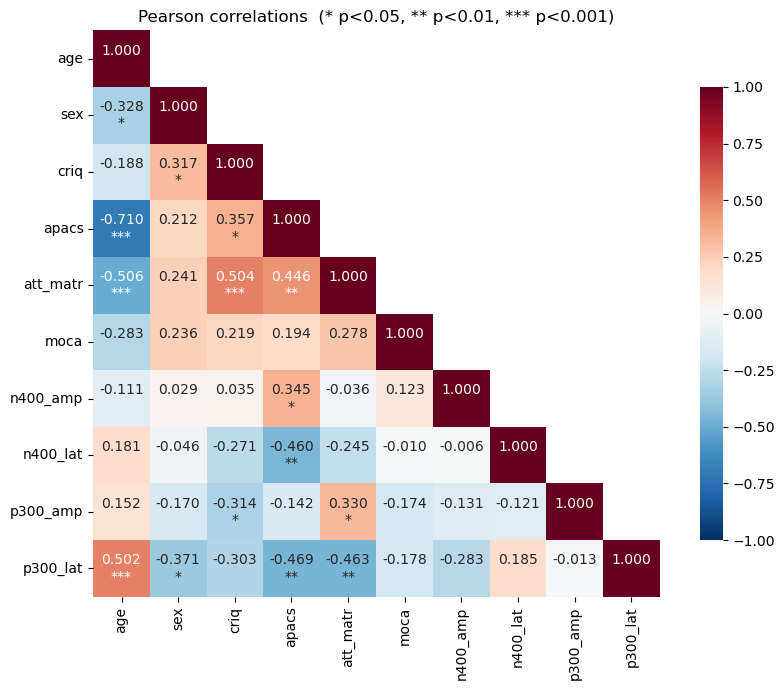

In [16]:
n_vars = len(vars)
valid = df[vars].dropna()

corr_mat = np.zeros((n_vars, n_vars))
p_mat    = np.ones((n_vars, n_vars))
for i, c1 in enumerate(vars):
    for j, c2 in enumerate(vars):
        if i == j:
            corr_mat[i, j] = 1.0
            p_mat[i, j] = 1.0
        else:
            r, p = pearsonr(valid[c1], valid[c2])
            corr_mat[i, j] = r
            p_mat[i, j] = p

star = np.full((n_vars, n_vars), "", dtype=object)
star[p_mat < 0.05]  = "*"
star[p_mat < 0.01]  = "**"
star[p_mat < 0.001] = "***"
annot = np.array([f"{corr_mat[i,j]:.3f}\n{star[i,j]}"
                  for i in range(n_vars) for j in range(n_vars)]).reshape(n_vars, n_vars)

fig_corr, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, annot=annot, fmt="", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, ax=ax,
            yticklabels=[v for v in vars],
            xticklabels=[v for v in vars],
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlations  (* p<0.05, ** p<0.01, *** p<0.001)")
plt.tight_layout()
plt.show()

> **What do we see in the plot?**
>
> Each cell shows the Pearson correlation coefficient (*r*) between a pair of variables. Colours indicate direction: red = positive, blue = negative. Intensity reflects strength (closer to ±1 = stronger).
>
> ***Pearson correlation*** - Values range from −1 (perfect negative) to +1 (perfect positive). A value near 0 means no linear relationship. 
>
> ***Significance*** - Stars indicate whether the correlation is statistically significant: * p<0.05, ** p<0.01, *** p<0.001. The lower the p-value, the stronger the evidence that the correlation is not due to chance.

#### Key hypothesised associations

Based on the literature, we focus on two key pairs and generate scatter plots
with regression lines and 95 % confidence bands.

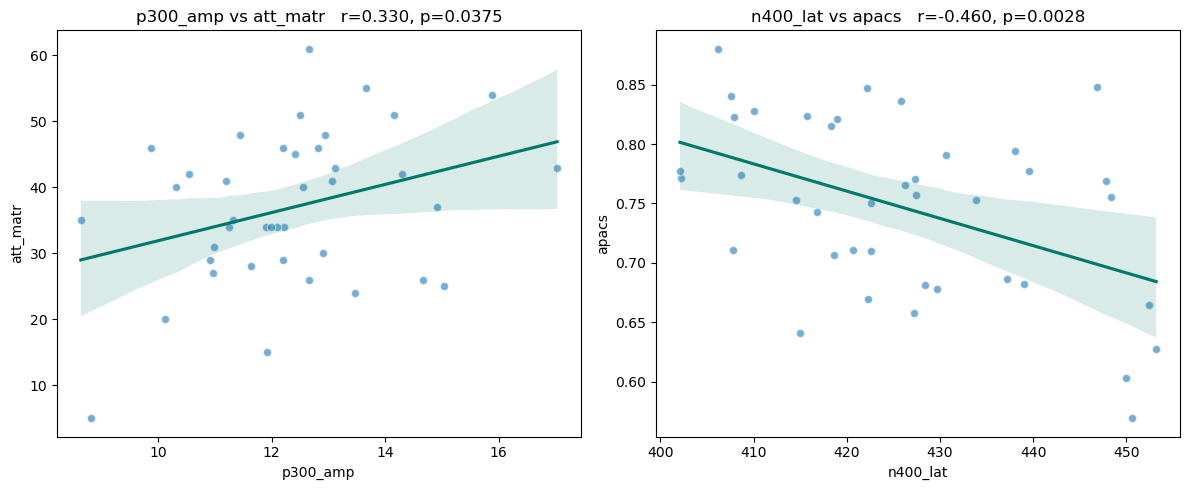

In [17]:
pairs = [("p300_amp", "att_matr"), ("n400_lat", "apacs")]

fig_scatter, axes = plt.subplots(1, 2, figsize=(12, 5))
if len(pairs) == 1:
    axes = [axes]
for ax, (x_name, y_name) in zip(axes, pairs):
    v = df[[x_name, y_name]].dropna()
    sns.regplot(data=v, x=x_name, y=y_name, ax=ax,
                scatter_kws={"alpha": 0.6, "edgecolor": "white"},
                line_kws={"color": "#00796B"})
    r, p = pearsonr(v[x_name], v[y_name])
    ax.set_title(f"{x_name} vs {y_name}   r={r:.3f}, p={p:.4f}")
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
plt.tight_layout()
plt.show()

> **What do we see in the plot?**
>
> Each dot shows the values of one participant. 
> 
> The **regression line** shows the best-fit linear relationship — upward slope = positive association, flat = none. 
> 
> The **shaded band** is the 95 % confidence interval: narrower = more precise estimate, wider = more uncertainty (typically at the extremes). If the band includes a horizontal line, the slope may not be significant. 
> 
> The **r** value (Pearson correlation coefficient) quantifies strength (−1 to +1); **p** tests whether it is significantly different from zero.

### 2.3 General linear models

We fit three models, each with a different structure. This reflects the
reality of clinical research: sometimes we have a clear theoretical
prediction, sometimes we explore, and sometimes we learn from our mistakes
and simplify.

---

#### APACS - A theory-driven model

Descrizione di modello teorico per APACS

*APACS ~ N400_lat + N400_amp + Age*


In [18]:
mod_apacs_formula = "apacs ~ n400_lat + n400_amp + age"

mod_apacs = smf.glm(formula=mod_apacs_formula, data=df, family=sm.families.Gaussian()).fit() 

print(mod_apacs.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  apacs   No. Observations:                   40
Model:                            GLM   Df Residuals:                       36
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                       0.0018202
Method:                          IRLS   Log-Likelihood:                 71.525
Date:                Thu, 17 Sep 2026   Deviance:                     0.065529
Time:                        17:10:23   Pearson chi2:                   0.0655
No. Iterations:                     3   Pseudo R-squ. (CS):             0.8684
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7627      0.200      8.809      0.0

#### Attentive Matrices - A model with no a priori knowledge

Now we want to build a model for attentive matrices.

As known by the theory, and also shown in the previous correlation plot, attentive matrices are correlated to P300, education (CRIq), and age. 

But our dataset includes much more variables, therefore one idea could be *bigger is better: let's put everything together*

So we can try to fit a kitchen-sink model using all the data as covariates: *AttentiveMatrices ~ P300_lat + P300_amp + N400_lat + N400_amp + Age + Sex + CRIq*

We fit this model only to see what happens when theory is ignored and every available variable is thrown in — not to use its p-values to decide afterwards which variables to keep (see below).

In [19]:
mod_att_matr_full_formula = "att_matr ~ p300_lat + p300_amp + n400_lat + n400_amp + age + sex + criq"

mod_att_matr_full = smf.glm(formula=mod_att_matr_full_formula, data=df, family=sm.families.Gaussian()).fit() 

print(mod_att_matr_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               att_matr   No. Observations:                   40
Model:                            GLM   Df Residuals:                       32
Model Family:                Gaussian   Df Model:                            7
Link Function:               Identity   Scale:                          39.568
Method:                          IRLS   Log-Likelihood:                -125.85
Date:                Thu, 17 Sep 2026   Deviance:                       1266.2
Time:                        17:10:25   Pearson chi2:                 1.27e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9133
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -38.0565     47.029     -0.809      0.4

#### Attentive Matrices - A theory-guided, parsimonious model

The kitchen-sink model above shows the cost of ignoring theory: several
predictors are far from significant, and entering redundant or
theoretically unmotivated variables inflates standard errors and
destabilises the coefficients.

Importantly, we do **not** decide which variables to keep by looking at
*these* p-values — that would be post-hoc pruning, a form of circular
reasoning: the same data would first be searched to select the model and
then reused to test it, inflating the apparent evidence for whatever
survives. Instead we go back to theory and to the earlier bivariate
analysis (Section 2.2): P300 amplitude, age, and CRIq are the established
covariates for attentional performance, so those are the predictors we
keep *a priori*. N400 amplitude/latency and P300 latency are dropped
because there is no theoretical reason to expect them to explain attentive
matrices performance specifically, and `sex` is dropped on the same a
priori grounds — not because it failed to reach significance above.

*Attentive Matrices ~ P300_amp + Age + CRIq*

In [20]:
mod_att_matr_pars_formula = "att_matr ~ p300_amp + age + criq"

mod_att_matr_pars = smf.glm(formula=mod_att_matr_pars_formula, data=df, family=sm.families.Gaussian()).fit() 

print(mod_att_matr_pars.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               att_matr   No. Observations:                   40
Model:                            GLM   Df Residuals:                       36
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          36.746
Method:                          IRLS   Log-Likelihood:                -126.73
Date:                Thu, 17 Sep 2026   Deviance:                       1322.9
Time:                        17:10:26   Pearson chi2:                 1.32e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9239
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -24.4865     15.390     -1.591      0.1

This theory-guided model has fewer predictors, and — as a consequence, not
as the reason we chose them — all of them are significant and the model is
more stable. Because the selection was made a priori rather than by
trimming non-significant terms, the improved fit (comparable or better R²
with fewer parameters) can be read as genuine evidence in favour of
parsimony, rather than as an artefact of having searched the data for
whichever subset happens to look best.

> **Takeaway**
>
> More variables does not mean a better model — and *how* you choose which
> variables to drop matters just as much as the decision to drop them.
> Selecting predictors *after* seeing that they are not significant in a
> bigger model is a form of post hoc pruning, which is circular: the same
> data end up being used both to choose the model and to test it, which
> inflates the apparent evidence for whatever predictors remain.
>
> Here the predictors were instead chosen **a priori**, from theory and
> from the earlier correlation analysis (Section 2.2), before looking at
> any p-value from the kitchen-sink model. The kitchen-sink model was fit
> only to *illustrate* the cost of ignoring theory — inflated standard
> errors, an unstable intercept — not to guide which variables to keep.
> That the resulting theory-driven model also turns out to fit at least as
> well (higher pseudo R², all coefficients significant, and a simpler,
> more interpretable structure) is a welcome confirmation, not the
> justification for the choice.

### 2.4 Assumption checking (post-hoc)

Fitting a model is not the last step: linear regression relies on a few
assumptions, and good practice is to check them **after** fitting, before
trusting the coefficients. We do this here for the final, parsimonious
Attentive Matrices model (`att_matr ~ p300_amp + age + criq`).

- **Linearity & homoscedasticity** — residuals plotted against fitted values
  should scatter randomly around zero, with no funnel shape or curve.
- **Normality of residuals** — a Q-Q plot of the residuals should follow the
  diagonal (same logic as the Q-Q plots in Section 1.4, now applied to the
  model's errors instead of the raw variables).
- **Influential observations** — Cook's distance flags participants who, on
  their own, pull the fitted model strongly in one direction. A common rule
  of thumb is to inspect points above 4/n.
- **Multicollinearity** — the Variance Inflation Factor (VIF) quantifies how
  much a predictor's variance is inflated by correlation with the other
  predictors. VIF > 5 is a moderate concern, VIF > 10 is severe (see
  Section 1.6 of the pipeline). The intercept is excluded from the VIF
  table/plot below, since its VIF is a statistical artefact with no
  interpretation as a collinearity check.

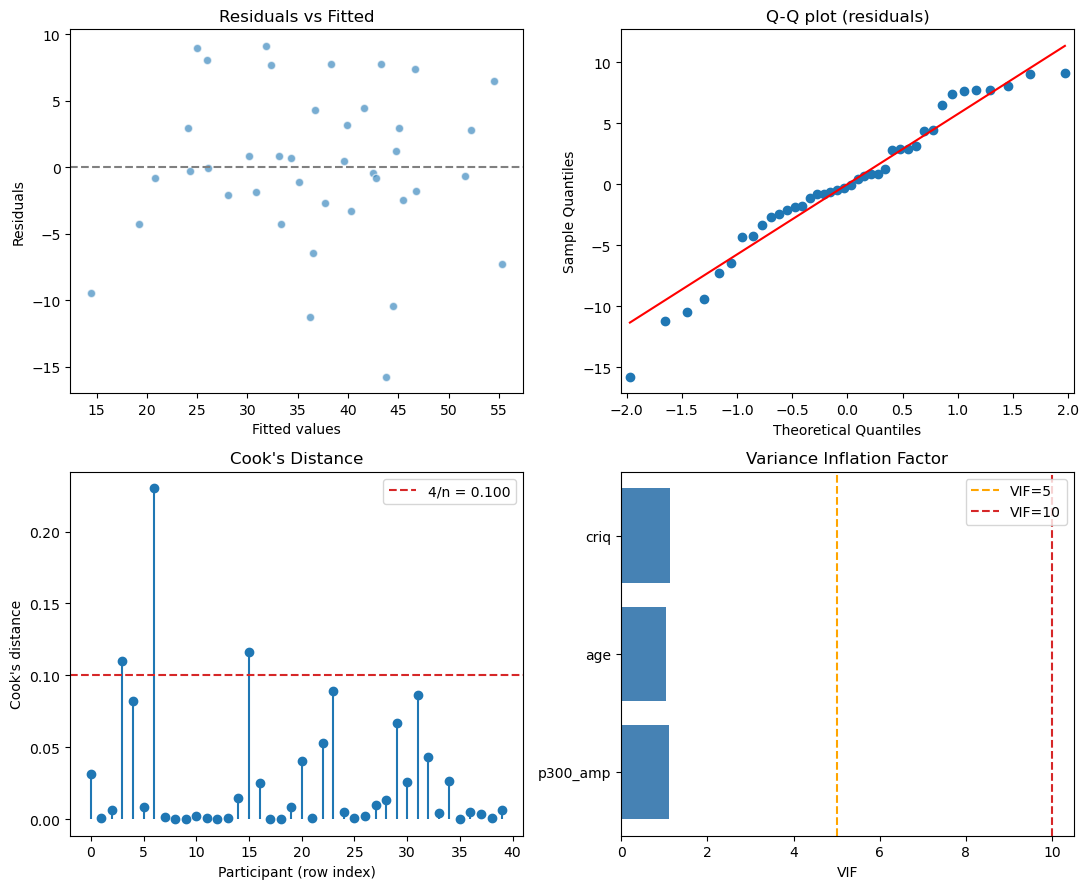

predictor      VIF
 p300_amp 1.120226
      age 1.047077
     criq 1.134707

Participants above the 4/n Cook's distance threshold: 3 (max Cook's D = 0.230)


In [21]:
mod = mod_att_matr_pars
predictors = ["p300_amp", "age", "criq"]

fitted = mod.fittedvalues
resid  = mod.resid_response
n      = int(mod.nobs)

fig_diag, axes = plt.subplots(2, 2, figsize=(11, 9))

# Residuals vs fitted
axes[0, 0].scatter(fitted, resid, alpha=0.6, edgecolor="white")
axes[0, 0].axhline(0, color="gray", ls="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# Q-Q plot of residuals
sm.qqplot(resid, line="s", ax=axes[0, 1])
axes[0, 1].set_title("Q-Q plot (residuals)")

# Cook's distance
influence = mod.get_influence()
cooks = influence.cooks_distance[0]
axes[1, 0].stem(range(n), cooks, basefmt=" ")
axes[1, 0].axhline(4 / n, color="C3", ls="--", label=f"4/n = {4/n:.3f}")
axes[1, 0].set_xlabel("Participant (row index)")
axes[1, 0].set_ylabel("Cook's distance")
axes[1, 0].set_title("Cook's Distance")
axes[1, 0].legend()

# Variance Inflation Factor (intercept excluded: its VIF is not meaningful
# and is typically orders of magnitude larger than the predictors' values)
X_vif = add_constant(df[predictors])
vif_table = pd.DataFrame({
    "predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_table = vif_table[vif_table["predictor"] != "const"].reset_index(drop=True)
axes[1, 1].barh(vif_table["predictor"], vif_table["VIF"], color="steelblue")
axes[1, 1].axvline(5, color="orange", ls="--", label="VIF=5")
axes[1, 1].axvline(10, color="C3", ls="--", label="VIF=10")
axes[1, 1].set_xlabel("VIF")
axes[1, 1].set_title("Variance Inflation Factor")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(vif_table.to_string(index=False))
n_influential = int((cooks > 4 / n).sum())
print(f"\nParticipants above the 4/n Cook's distance threshold: {n_influential} (max Cook's D = {cooks.max():.3f})")

> **What do we see in the plot?**
>
> ***Residuals vs Fitted*** — no funnel shape or curve should be visible; a
> random scatter around zero supports linearity and constant variance
> (homoscedasticity).
>
> ***Q-Q plot (residuals)*** — points should lie close to the diagonal;
> systematic curvature would suggest non-normal errors.
>
> ***Cook's distance*** — a handful of points above the 4/n line is not
> unusual with n = 40 and, on its own, is not a red flag: what matters is
> whether any point stands out with a much larger value than the rest (a
> useful check is to refit the model without that participant and see
> whether the coefficients change materially).
>
> ***VIF*** — values close to 1 mean each predictor carries mostly
> independent information; here `p300_amp`, `age`, and `criq` all sit well
> below the VIF = 5 caution threshold, so multicollinearity is not a
> concern for this model.

**Interpretation:** for the parsimonious Attentive Matrices model, the
diagnostics are reassuring — residuals show no obvious pattern, the Q-Q
plot is close to the diagonal, no participant has a disproportionately
large Cook's distance, and VIF values are low. This supports treating the
model's coefficients (Section 2.3) at face value.

---
## 3. Export

We now save the results that matter most for a clinical audience: the key
**figures** (as PNG images, ready to paste into a report or a slide) and
the key **tables** (as both `.csv` — universal, opens anywhere — and
`.xlsx` — a single Excel workbook with one sheet per table, easier to
browse for those who are not used to statistical software).

Nothing here is recomputed: we simply save the figures and tables already
produced above.

### 3.1 Figures

We save the figures produced earlier in the notebook, one PNG per figure.

In [22]:
figures_to_save = {
    "A_missingness.png":               fig_missing,
    "B_distributions.png":             fig_dist,
    "C_correlations.png":              fig_corr,
    "D_key_associations.png":          fig_scatter,
    "E_diagnostics_attentive_matrices.png": fig_diag,
}

for filename, fig in figures_to_save.items():
    path = FIGS / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

Saved: CaseStudy_1/outputs/figures/A_missingness.png
Saved: CaseStudy_1/outputs/figures/B_distributions.png
Saved: CaseStudy_1/outputs/figures/C_correlations.png
Saved: CaseStudy_1/outputs/figures/D_key_associations.png
Saved: CaseStudy_1/outputs/figures/E_diagnostics_attentive_matrices.png


### 3.2 Tables

We export four tables:

1. **Descriptive statistics** (`table1`, already built in Section 2.1)
2. **Bivariate correlations** — every pair of variables, one row per pair
   (long/tidy format, easier to filter and sort in Excel than a matrix)
3. **Regression results** — coefficients, standard errors, p-values and
   95% CI for all three models (APACS, and both Attentive Matrices models)
4. **Multicollinearity check (VIF)** — for the parsimonious Attentive
   Matrices model (Section 2.4)

Each table gets a `Significant (p<0.05)` column so it is immediately clear,
without reading p-values, which associations/predictors reach conventional
significance.

In [23]:
# Table 2 — bivariate correlations, one row per unique pair of variables
corr_rows = []
for i in range(n_vars):
    for j in range(i + 1, n_vars):
        corr_rows.append({
            "Variable 1": vars[i],
            "Variable 2": vars[j],
            "r": corr_mat[i, j],
            "p-value": p_mat[i, j],
            "Significant (p<0.05)": p_mat[i, j] < 0.05,
        })
table2_correlations = pd.DataFrame(corr_rows)
table2_correlations.head()

,Variable 1,Variable 2,r,p-value,Significant (p<0.05)
0,age,sex,-0.327699,3.899762e-02,True
1,age,criq,-0.188309,2.445653e-01,False
2,age,apacs,-0.710048,2.878280e-07,True
3,age,att_matr,-0.505857,8.686831e-04,True
4,age,moca,-0.283492,7.628318e-02,False


In [24]:
# Table 3 — regression coefficients for all three fitted models
def model_to_table(model, outcome_label):
    ci = model.conf_int()
    ci.columns = ["CI_lower", "CI_upper"]
    out = pd.DataFrame({
        "Predictor":   model.params.index,
        "Estimate":    model.params.values,
        "Std. Error":  model.bse.values,
        "p-value":     model.pvalues.values,
    }).set_index("Predictor").join(ci)
    out.insert(0, "Outcome", outcome_label)
    out["Significant (p<0.05)"] = out["p-value"] < 0.05
    return out.reset_index()

table3_regression = pd.concat([
    model_to_table(mod_apacs, "APACS (theory-driven)"),
    model_to_table(mod_att_matr_full, "Attentive Matrices (kitchen-sink)"),
    model_to_table(mod_att_matr_pars, "Attentive Matrices (parsimonious)"),
], ignore_index=True)
table3_regression

,Predictor,Outcome,Estimate,Std. Error,p-value,CI_lower,CI_upper,Significant (p<0.05)
0,Intercept,APACS (theory-driven),1.762732,0.200113,1.266186e-18,1.370518,2.154946,True
1,n400_lat,APACS (theory-driven),-0.001730,0.000469,2.286062e-04,-0.002650,-0.000810,True
2,n400_amp,APACS (theory-driven),0.023180,0.007860,3.187508e-03,0.007774,0.038586,True
3,age,APACS (theory-driven),-0.005513,0.000845,6.996230e-11,-0.007170,-0.003856,True
4,Intercept,Attentive Matrices (kitchen-sink),-38.056537,47.028945,4.183914e-01,-130.231576,54.118503,False
5,p300_lat,Attentive Matrices (kitchen-sink),-0.045957,0.073007,5.290333e-01,-0.189048,0.097134,False
6,p300_amp,Attentive Matrices (kitchen-sink),3.833714,0.643971,2.628883e-09,2.571553,5.095874,True
7,n400_lat,Attentive Matrices (kitchen-sink),0.070465,0.073829,3.398612e-01,-0.074237,0.215167,False
8,n400_amp,Attentive Matrices (kitchen-sink),-0.678295,1.227758,5.806287e-01,-3.084656,1.728065,False
9,age,Attentive Matrices (kitchen-sink),-0.658100,0.146922,7.490303e-06,-0.946061,-0.370139,True


In [25]:
# Table 4 — VIF table computed in Section 2.4 (Attentive Matrices, parsimonious model)
table4_vif = vif_table.rename(columns={"predictor": "Predictor"})
table4_vif

,Predictor,VIF
0,p300_amp,1.120226
1,age,1.047077
2,criq,1.134707


In [26]:
tables_to_save = {
    "table1_descriptives.csv":  table1,
    "table2_correlations.csv":  table2_correlations,
    "table3_regression.csv":    table3_regression,
    "table4_vif.csv":           table4_vif,
}

# Save each table as its own CSV ...
for filename, table in tables_to_save.items():
    path = RESULTS / filename
    table.to_csv(path, index=False)
    print(f"Saved: {path}")

# ... and all four together as a single Excel workbook, one sheet per table
xlsx_path = RESULTS / "CaseStudy_1_results.xlsx"
with pd.ExcelWriter(xlsx_path) as writer:
    table1.to_excel(writer, sheet_name="Descriptives", index=False)
    table2_correlations.to_excel(writer, sheet_name="Correlations", index=False)
    table3_regression.to_excel(writer, sheet_name="Regression", index=False)
    table4_vif.to_excel(writer, sheet_name="VIF", index=False)
print(f"Saved: {xlsx_path}")

Saved: CaseStudy_1/outputs/results/table1_descriptives.csv
Saved: CaseStudy_1/outputs/results/table2_correlations.csv
Saved: CaseStudy_1/outputs/results/table3_regression.csv
Saved: CaseStudy_1/outputs/results/table4_vif.csv
Saved: CaseStudy_1/outputs/results/CaseStudy_1_results.xlsx


---
## 4. Strengths and limitations of this approach (Section 4.2.3)

**Strengths:**
- Reduces high-dimensional EEG to **4 interpretable scalar features** per
  participant — theoretically grounded, easy to communicate
- Uses **well-established statistical models** (OLS regression) familiar to
  clinical researchers
- The N400 and P300 have **decades of validation** across neurological
  populations (Kutas & Federmeier, 2011; Polich, 2007)

**Limitations:**
- Strong **a priori decisions** about time windows and electrode sets may
  miss atypical or distributed neural patterns — especially relevant in
  stroke patients whose ERP topography may differ from normative expectations
- **Trial-to-trial variability** is discarded (only mean amplitude and peak
  latency are kept), which may itself carry clinically relevant information
- The **hypothesis-driven** nature of the approach means it will not detect
  effects outside the predefined features — for broader exploration, see
  Case Study 2 (spectral analysis)

> For a full discussion, see Section 4.2 of the companion paper.

---

*Notebook generated for the EEG-NPSI tutorial. All code is self-contained
for transparency and reproducibility.*